<a href="https://colab.research.google.com/github/JiyaroJoseph/PSCDL-2026-Challenge/blob/main/PSCDL_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/PSCDL_2026"

print(os.listdir(dataset_path))

['video_5', 'video_3', 'PSCDL_2026.pdf', 'video_2', 'video_1', 'video_4']


In [ ]:
import cv2

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

duration = total_frames / fps

print("FPS:", fps)
print("Resolution:", width, "x", height)
print("Total Frames:", total_frames)
print("Duration:", duration)

cap.release()

FPS: 15.0
Resolution: 1920 x 1080
Total Frames: 3615
Duration: 241.0


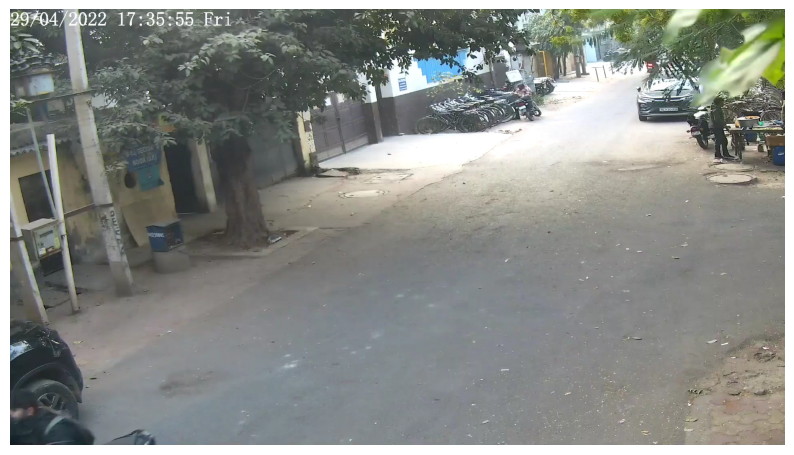

In [ ]:
import cv2
import matplotlib.pyplot as plt

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

cap.release()

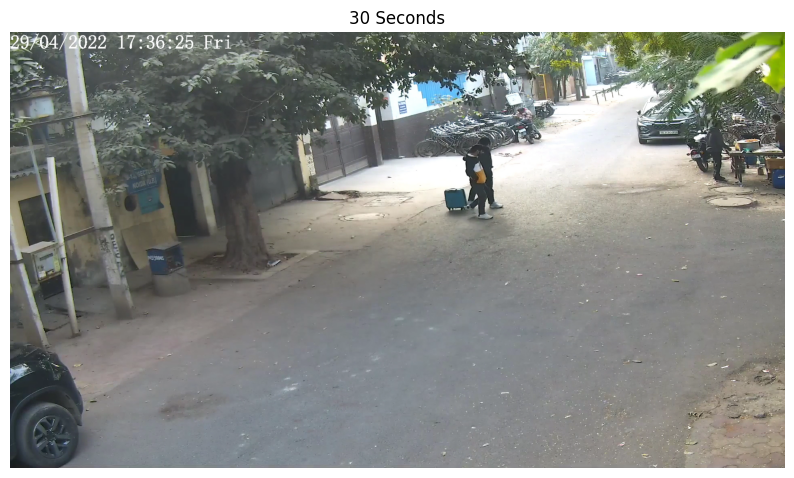

In [ ]:
import cv2
import matplotlib.pyplot as plt

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)

target_time = 30
target_frame = int(target_time * fps)

cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.title("30 Seconds")
plt.axis("off")
plt.show()

cap.release()

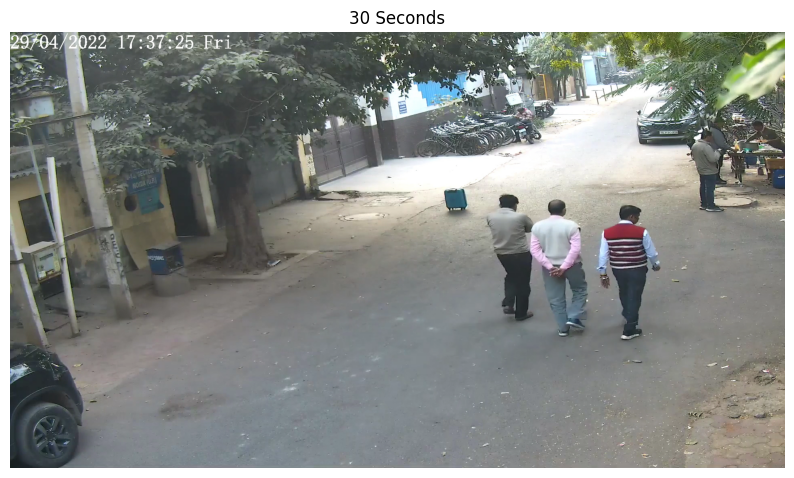

In [ ]:
import cv2
import matplotlib.pyplot as plt

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)

fps = cap.get(cv2.CAP_PROP_FPS)

target_time = 90
target_frame = int(target_time * fps)

cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)

ret, frame = cap.read()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,6))
plt.imshow(frame_rgb)
plt.title("30 Seconds")
plt.axis("off")
plt.show()

cap.release()

In [ ]:
import os

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

print("Exists:", os.path.exists(VIDEO_PATH))
print("File:", VIDEO_PATH)

Exists: False
File: /content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4


In [ ]:
import os

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

print("Exists:", os.path.exists(VIDEO_PATH))
print("File:", VIDEO_PATH)

Exists: False
File: /content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4


In [ ]:
import cv2

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

cap = cv2.VideoCapture(VIDEO_PATH)
print("Opened:", cap.isOpened())

ret, frame = cap.read()
print("Read frame:", ret)
print("Frame shape:", frame.shape if ret else "FAILED")

fps          = cap.get(cv2.CAP_PROP_FPS)
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration     = total_frames / fps

print(f"FPS: {fps}")
print(f"Resolution: {width} x {height}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration:.1f}s")

cap.release()

Opened: False
Read frame: False
Frame shape: FAILED


ZeroDivisionError: float division by zero

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".mp4"):
            print(os.path.join(root, file))

In [ ]:
from google.colab import drive
drive.unmount('/content/drive')
drive.mount('/content/drive', force_remount=True)

AttributeError: module 'google.colab.drive' has no attribute 'unmount'

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
import cv2

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"

print("Exists:", os.path.exists(VIDEO_PATH))

cap = cv2.VideoCapture(VIDEO_PATH)
print("Opened:", cap.isOpened())
cap.release()

Exists: True
Opened: True


Background built from 375 frames (25s)


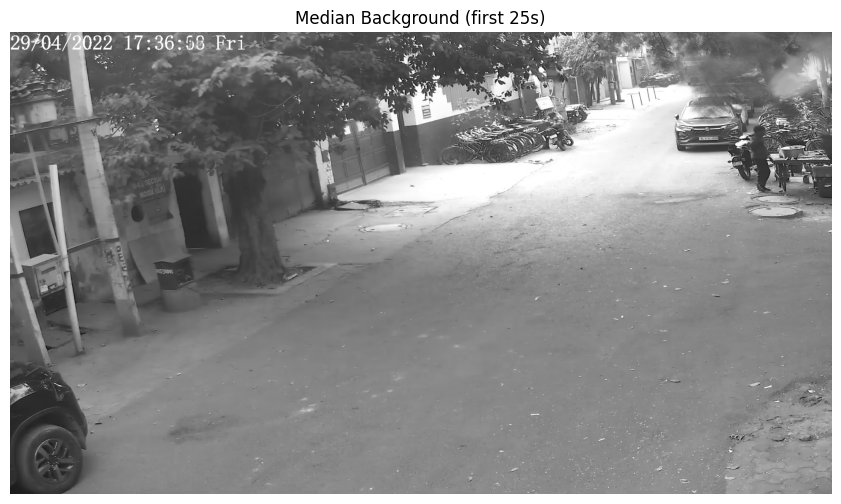

Processed 241 seconds


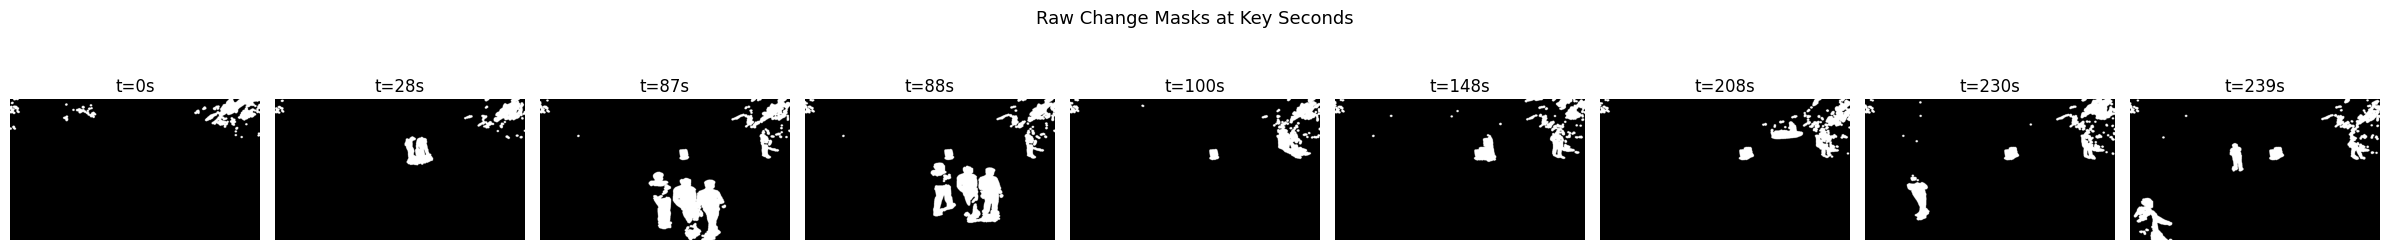

Output masks generated: 241


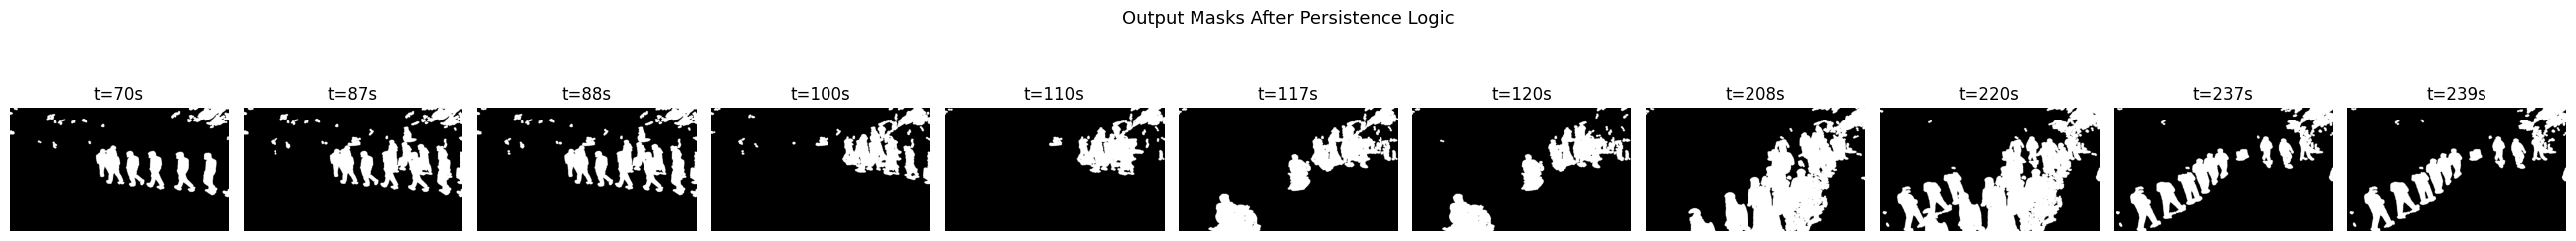

Saved 241 masks to /content/drive/MyDrive/PSCDL_2026/video_1/output_masks


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

VIDEO_PATH = "/content/drive/MyDrive/PSCDL_2026/video_1/video_1.mp4"
fps = 15.0

def build_background(video_path, fps, bg_seconds=25):
    cap = cv2.VideoCapture(video_path)
    frames = []
    max_frames = int(fps * bg_seconds)
    for i in range(max_frames):
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(gray)
    cap.release()
    background = np.median(np.array(frames), axis=0).astype(np.uint8)
    print(f"Background built from {len(frames)} frames ({bg_seconds}s)")
    return background

background = build_background(VIDEO_PATH, fps, bg_seconds=25)

plt.figure(figsize=(12, 6))
plt.imshow(background, cmap='gray')
plt.title("Median Background (first 25s)")
plt.axis("off")
plt.show()




def detect_changes_per_second(video_path, background, fps, threshold=25):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = int(total_frames / fps)
    change_masks = {}

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    for sec in range(duration):
        target_frame = int(sec * fps + fps // 2)
        cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        diff = cv2.absdiff(gray, background)
        _, raw_mask = cv2.threshold(diff, threshold, 255, cv2.THRESH_BINARY)
        mask = cv2.morphologyEx(raw_mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.dilate(mask, kernel, iterations=2)
        change_masks[sec] = mask

    cap.release()
    print(f"Processed {len(change_masks)} seconds")
    return change_masks

change_masks = detect_changes_per_second(VIDEO_PATH, background, fps, threshold=25)



# Based on video_1 ground truth:
# bag-1 introduced at 28s → active at 88s → cooldown at 118s
# bag-2 introduced at 148s → active at 208s → cooldown at 238s

check_seconds = [0, 28, 87, 88, 100, 148, 208, 230, 239]

fig, axes = plt.subplots(1, len(check_seconds), figsize=(24, 3))
for ax, sec in zip(axes, check_seconds):
    ax.imshow(change_masks[sec], cmap='gray')
    ax.set_title(f"t={sec}s")
    ax.axis('off')
plt.suptitle("Raw Change Masks at Key Seconds", fontsize=13)
plt.tight_layout()
plt.show()



def apply_persistence_logic(change_masks, fps, p, c, min_blob_area=500):
    """
    p = persistence threshold (seconds)
    c = cooldown period (seconds)

    An object is flagged only if:
      - it has been continuously present for >= p seconds
      - AND fewer than c seconds have passed since it first appeared
    """
    duration = len(change_masks)

    # tracked_objects: list of dicts
    # { 'first_seen': int, 'last_seen': int, 'mask': np.array }
    tracked_objects = []

    # For each second, find blobs
    def get_blobs(mask, min_area):
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)
        blobs = []
        for i in range(1, num_labels):  # skip background label 0
            area = stats[i, cv2.CC_STAT_AREA]
            if area >= min_area:
                blob_mask = (labels == i).astype(np.uint8) * 255
                cx, cy = centroids[i]
                blobs.append({'mask': blob_mask, 'cx': cx, 'cy': cy, 'area': area})
        return blobs

    def centroid_distance(b1, b2):
        return np.sqrt((b1['cx'] - b2['cx'])**2 + (b1['cy'] - b2['cy'])**2)

    # Track blobs across seconds
    for sec in range(duration):
        current_blobs = get_blobs(change_masks[sec], min_blob_area)

        matched_ids = set()
        for blob in current_blobs:
            best_match = None
            best_dist = float('inf')
            for i, obj in enumerate(tracked_objects):
                if i in matched_ids:
                    continue
                # Only match if object was seen recently (within 5s gap)
                if sec - obj['last_seen'] > 5:
                    continue
                dist = centroid_distance(blob, {'cx': obj['cx'], 'cy': obj['cy']})
                if dist < 80 and dist < best_dist:  # 80px centroid tolerance
                    best_dist = dist
                    best_match = i

            if best_match is not None:
                # Update existing object
                tracked_objects[best_match]['last_seen'] = sec
                tracked_objects[best_match]['mask'] = blob['mask']
                tracked_objects[best_match]['cx'] = blob['cx']
                tracked_objects[best_match]['cy'] = blob['cy']
                matched_ids.add(best_match)
            else:
                # New object
                tracked_objects.append({
                    'first_seen': sec,
                    'last_seen': sec,
                    'mask': blob['mask'],
                    'cx': blob['cx'],
                    'cy': blob['cy']
                })

    # Now generate final output masks
    # Masks start from second (p + 10) as per spec
    start_sec = p + 10
    output_masks = {}

    for sec in range(duration):
        if sec < start_sec:
            # Before (p+10), always blank
            h, w = background.shape
            output_masks[sec] = np.zeros((h, w), dtype=np.uint8)
            continue

        combined = np.zeros_like(background)
        for obj in tracked_objects:
            age = sec - obj['first_seen']
            if age >= p and age < c:
                combined = cv2.bitwise_or(combined, obj['mask'])

        output_masks[sec] = combined

    return output_masks

# Run with video_1 parameters
output_masks = apply_persistence_logic(change_masks, fps, p=60, c=90, min_blob_area=500)
print(f"Output masks generated: {len(output_masks)}")



check_seconds = [70, 87, 88, 100, 110, 117, 120, 208, 220, 237, 239]

fig, axes = plt.subplots(1, len(check_seconds), figsize=(26, 3))
for ax, sec in zip(axes, check_seconds):
    ax.imshow(output_masks[sec], cmap='gray')
    ax.set_title(f"t={sec}s")
    ax.axis('off')
plt.suptitle("Output Masks After Persistence Logic", fontsize=13)
plt.tight_layout()
plt.show()



import os

OUTPUT_DIR = "/content/drive/MyDrive/PSCDL_2026/video_1/output_masks"
os.makedirs(OUTPUT_DIR, exist_ok=True)

duration = len(output_masks)
for sec in range(duration):
    filename = f"mask_{str(sec+1).zfill(4)}.png"
    filepath = os.path.join(OUTPUT_DIR, filename)
    cv2.imwrite(filepath, output_masks[sec])

print(f"Saved {duration} masks to {OUTPUT_DIR}")


